In [ ]:
%pip install kagglehub

In [1]:
import kagglehub
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\anant\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2


In [2]:
import os
print(os.listdir(path))

['train.csv']


In [3]:
import pandas as pd
df = pd.read_csv(path + "/train.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d/%m/%Y")
df = df.sort_values('Order Date')

In [8]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

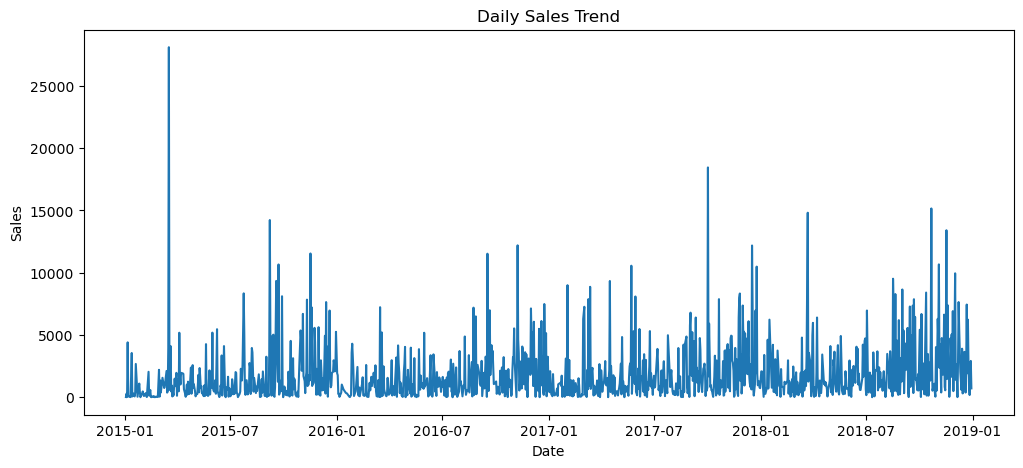

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller
res = adfuller(daily_sales)
print(res[1])

5.669526815779501e-07


In [11]:
daily_sales_diff = daily_sales.diff().dropna()
print(daily_sales_diff)

Order Date
2015-01-04     271.6120
2015-01-05    -268.5240
2015-01-06    4387.5640
2015-01-07   -4319.9420
2015-01-09     -46.6140
                ...    
2018-12-26   -1884.3330
2018-12-27    -636.9580
2018-12-28    1479.7148
2018-12-29    1258.1832
2018-12-30   -2201.7440
Name: Sales, Length: 1229, dtype: float64


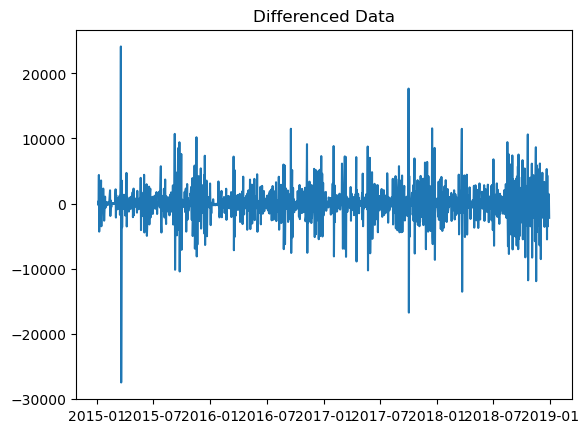

In [12]:
plt.plot(daily_sales_diff)
plt.title("Differenced Data")
plt.show()

In [13]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(daily_sales,order = (1,1,1))
model_fit = model.fit()
print(model_fit.summary())

C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1230
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -11230.551
Date:                Tue, 31 Mar 2026   AIC                          22467.102
Time:                        07:26:40   BIC                          22482.444
Sample:                             0   HQIC                         22472.875
                               - 1230                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0392      0.029      1.344      0.179      -0.018       0.096
ma.L1         -0.9674      0.008   -123.858      0.000      -0.983      -0.952
sigma2      5.058e+06   6.34e+04     79.794      0.0

In [14]:
forecast = model_fit.forecast(steps=30)
print(forecast)

1230    2870.640586
1231    2955.274523
1232    2958.595524
1233    2958.725839
1234    2958.730952
1235    2958.731153
1236    2958.731161
1237    2958.731161
1238    2958.731161
1239    2958.731161
1240    2958.731161
1241    2958.731161
1242    2958.731161
1243    2958.731161
1244    2958.731161
1245    2958.731161
1246    2958.731161
1247    2958.731161
1248    2958.731161
1249    2958.731161
1250    2958.731161
1251    2958.731161
1252    2958.731161
1253    2958.731161
1254    2958.731161
1255    2958.731161
1256    2958.731161
1257    2958.731161
1258    2958.731161
1259    2958.731161
Name: predicted_mean, dtype: float64


C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


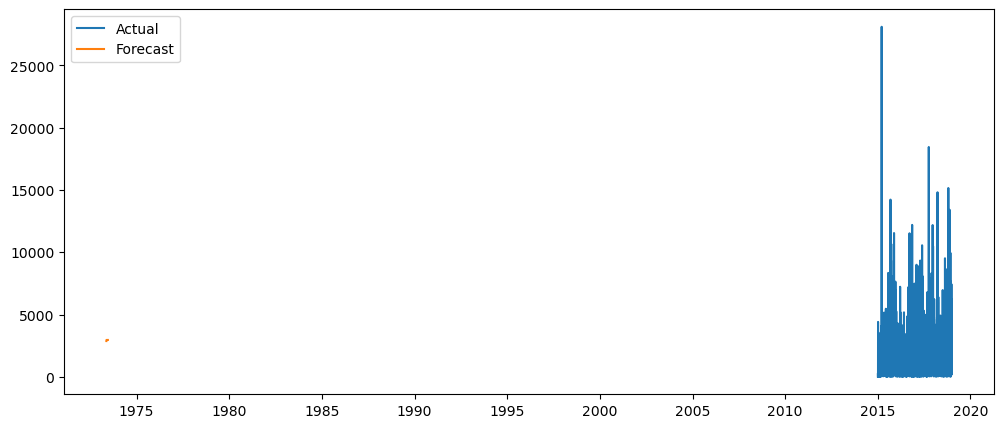

In [15]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales, label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error
import numpy as np

train = daily_sales[:-30]
test = daily_sales[-30:]

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

pred = model_fit.forecast(steps=30)

rmse = np.sqrt(mean_squared_error(test, pred))
print("RMSE:", rmse)

C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RMSE: 2545.239479887335


C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
